# Segmentación de Carreteras con Machine Learning

Este notebook implementa un sistema de aprendizaje automático para detectar carreteras en imágenes satelitales.

**Objetivo**: Comparar Random Forest, SVM y KNN para segmentación de carreteras.

**Pipeline**:
1. Carga de datos y extracción de características
2. Entrenamiento de modelos
3. Evaluación y comparación de resultados

## 0. Imports y Configuración Inicial

In [124]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, feature, morphology, exposure
from skimage.util import img_as_ubyte
from sklearn.metrics import jaccard_score, accuracy_score, f1_score

## 1. Funciones de Extracción de Características

Aplicamos múltiples filtros para obtener 13 características por píxel:
- Canales RGB suavizados
- HSV Saturación
- Lab (a, b)
- Sobel (bordes)
- DoG (Difference of Gaussians)
- Frangi (estructuras tubulares)
- Hessiana (curvatura)
- Entropía y gradiente morfológico

In [125]:
def normalizar_car(array):
    min_val = np.min(array)
    max_val = np.max(array)
    if max_val - min_val == 0: return array
    return (array - min_val) / (max_val - min_val)

def extraer_caracteristicas_pixel(image_rgb):
    caracteristicas = []
    # Preprocesado

    #equalize_adapthist implementa el algoritmo CLAHE: Mejora el contraste de forma local.
    #A diferencia de una ecualización global,
    #esta evita saturar áreas brillantes y ayuda a resaltar detalles en sombras.
    img_eq = exposure.equalize_adapthist(image_rgb, clip_limit=0.03)

    # Filtro gausiano. Aplica un desenfoque para reducir el ruido de alta frecuencia,
    # asegurando que los filtros posteriores
    # no interpreten ruido aleatorio como información relevante.
    img_smooth = filters.gaussian(img_eq, sigma=1, channel_axis=-1)


    gray = color.rgb2gray(img_smooth)

    #HSV Saturación. separar objetos por la pureza de su color,
    hsv = color.rgb2hsv(img_smooth)
    #Lab (a, b) El espacio Lab separa la luminosidad L de los componentes de color a y b.
    lab = color.rgb2lab(img_smooth)

    # recolectamos las características
    caracteristicas.append(img_smooth[:,:,0])
    caracteristicas.append(img_smooth[:,:,1])
    caracteristicas.append(img_smooth[:,:,2])
    caracteristicas.append(hsv[:,:,1])
    caracteristicas.append(normalizar_car(lab[:,:,1]))
    caracteristicas.append(normalizar_car(lab[:,:,2]))

    #Filtro Sobel. Calcula el gradiente de intensidad.
    #Resalta los bordes verticales y horizontales.
    #Sirve para encontrar siluetas
    edge_sobel = filters.sobel(gray)
    caracteristicas.append(normalizar_car(edge_sobel))

    # DoG (Difference of Gaussians)
    # Se obtiene restando una versión muy desenfocada de la imagen de una menos desenfocada.
    # Actúa como un filtro de paso de banda que resalta detalles y bordes
    dog = filters.gaussian(gray, sigma=1) - filters.gaussian(gray, sigma=8)
    caracteristicas.append(normalizar_car(dog))

    # Filtro Frangi
    # Este filtro está diseñado específicamente para detectar estructuras tubulares
    # o filamentosas (como vasos sanguíneos, carreteras o fibras).
    # Utiliza los autovalores de la matriz Hessiana para determinar como de parecido a un tubo es un píxel.
    frangi = filters.frangi(gray, sigmas=range(1, 4), black_ridges=False)
    caracteristicas.append(normalizar_car(frangi))

    # Matriz Hessiana
    # Se calcula a dos escalas (1.5 y 3.5). La matriz Hessiana mide la curvatura local de la intensidad de la imagen.
    # Los autovalores (eigenvalues) resultantes te dicen si estás en una zona plana, en una cresta (borde) o en un rincón.
    # Al extraer eigvals[0], estás capturando la curvatura principal de la superficie de la imagen.

    for escala in [1.5, 3.5]:
        H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')
        eigvals = feature.hessian_matrix_eigvals(H_elems)
        caracteristicas.append(normalizar_car(eigvals[0]))

    gray_ubyte = img_as_ubyte(gray)
    #mide el desorden o complejidad de las texturas de las que el pixel forma parte
    entropy = filters.rank.entropy(gray_ubyte, morphology.disk(3))
    caracteristicas.append(normalizar_car(entropy))

    #Este filtro resalta los limites de los objetos
    morph_grad = filters.rank.gradient(gray_ubyte, morphology.disk(2))
    caracteristicas.append(normalizar_car(morph_grad))

    return np.stack(caracteristicas, axis=-1)

## 2. Carga de Datos y Visualización Inicial

Cargamos las imágenes satelitales y sus etiquetas ground truth desde la carpeta local `roads/`

SAT: ['roads\\sat\\10078675_15.tiff', 'roads\\sat\\10228675_15.tiff', 'roads\\sat\\10228705_15.tiff']
GT: ['roads\\gt\\10078675_15.tif', 'roads\\gt\\10228675_15.tif', 'roads\\gt\\10228705_15.tif']


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Shape de la matriz de caracteristicas extraidas:(1500, 1500, 13)


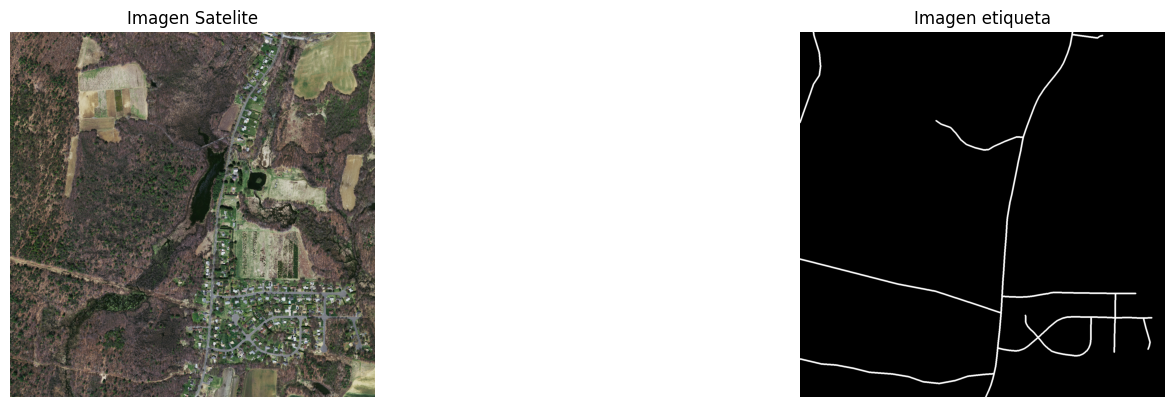

In [126]:
# Usa datos locales en 'roads' en esta carpeta
DIRBASE = os.path.join("roads")

fotos_satelite = glob.glob(os.path.join(DIRBASE, "sat", "*.tiff"))
fotos_gt = glob.glob(os.path.join(DIRBASE, "gt", "*.tif"))

fotos_satelite.sort()
fotos_gt.sort()

print("SAT:", fotos_satelite[:3])
print("GT:", fotos_gt[:3])

if len(fotos_satelite) == 0 or len(fotos_gt) == 0:
    raise FileNotFoundError(f"No se encontraron imágenes en {os.path.abspath(DIRBASE)}")

img_sat = io.imread(fotos_satelite[0])
img_gt = io.imread(fotos_gt[0], as_gray=True)

sat_car = extraer_caracteristicas_pixel(img_sat)
print(f"Shape de la matriz de caracteristicas extraidas:{sat_car.shape}")

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(img_sat); plt.title("Imagen Satelite"); plt.axis("off")
plt.subplot(133)
plt.imshow(img_gt, cmap='gray'); plt.title("Imagen etiqueta"); plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Preparación del Dataset

Vamos a cargar múltiples imágenes y preparar los datos para entrenar los modelos:
- **X**: Matriz de características (n_píxeles × 13)
- **y**: Vector de etiquetas binarias (0=no carretera, 1=carretera)

In [127]:
def preparar_datos(lista_sat, lista_gt, max_imagenes=None):
    """
    Carga múltiples imágenes y extrae características
    
    Args:
        lista_sat: Lista de rutas a imágenes satelitales
        lista_gt: Lista de rutas a ground truth
        max_imagenes: Número máximo de imágenes a procesar (None = todas)
    
    Returns:
        X: Matriz de características (n_píxeles, 13)
        y: Vector de etiquetas (n_píxeles,)
    """
    X_list = []
    y_list = []
    
    if max_imagenes is not None:
        lista_sat = lista_sat[:max_imagenes]
        lista_gt = lista_gt[:max_imagenes]
    
    for i, (path_sat, path_gt) in enumerate(zip(lista_sat, lista_gt)):
        print(f"Procesando imagen {i+1}/{len(lista_sat)}...", end="\r")
        
        # Cargar imágenes
        img_sat = io.imread(path_sat)
        img_gt = io.imread(path_gt, as_gray=True)
        
        # Extraer características (H × W × 13)
        features = extraer_caracteristicas_pixel(img_sat)
        
        # Aplanar a (H*W, 13)
        H, W, C = features.shape
        X_img = features.reshape(-1, C)
        
        # Preparar etiquetas: binarizar (>0.5 = carretera)
        y_img = (img_gt.ravel() > 0.5).astype(int)
        
        X_list.append(X_img)
        y_list.append(y_img)
    
    print(f"\nProcesadas {len(lista_sat)} imágenes correctamente")
    
    # Concatenar todas las imágenes
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    
    return X, y

In [128]:
# Cargar primeras imágenes para entrenamiento y prueba
# Usar 80% para train, 20% para test

n_total = len(fotos_satelite)
n_train = int(0.8 * n_total)

print(f"Total de imágenes: {n_total}")
print(f"Train: {n_train} | Test: {n_total - n_train}")

# Preparar datos de entrenamiento (todas las imágenes)
print("\n--- Preparando datos de entrenamiento ---")
X_train, y_train = preparar_datos(fotos_satelite, fotos_gt)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Proporción carretera/no-carretera: {y_train.mean():.3f}")

Total de imágenes: 20
Train: 16 | Test: 4

--- Preparando datos de entrenamiento ---


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


...

C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')



Procesadas 20 imágenes correctamente

X_train shape: (45000000, 13)
y_train shape: (45000000,)
Proporción carretera/no-carretera: 0.037


## 5. Entrenamiento de Modelos

Entrenaremos 3 clasificadores diferentes y compararemos sus resultados

In [129]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
import time

# Diccionario para almacenar resultados
resultados = {}

### 5.1 Random Forest

In [130]:
if len(X_train) > 500000:
    indices = resample(range(len(X_train)), n_samples=500000, random_state=42)
    X_train_sample = X_train[indices]
    y_train_sample = y_train[indices]
else:
    X_train_sample = X_train
    y_train_sample = y_train

print("\nEntrenando Random Forest:")
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20,
                                   random_state=42, n_jobs=-1, verbose=1,
                                   class_weight='balanced')
rf_model.fit(X_train_sample, y_train_sample)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['RF'] = {
    'modelo': rf_model,
    'tiempo': t1-t0
}


Entrenando Random Forest:


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   15.7s


Tiempo de entrenamiento: 59.31 segundos


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   58.7s finished


### 5.2 SVM (Support Vector Machine)

In [131]:
# SVM es más lento, reducimos muestra si es necesario
if len(X_train_sample) > 50000:
    indices_svm = resample(range(len(X_train_sample)), n_samples=50000, random_state=42)
    X_svm = X_train_sample[indices_svm]
    y_svm = y_train_sample[indices_svm]
else:
    X_svm = X_train_sample
    y_svm = y_train_sample

print("\nEntrenando SVM:")
t0 = time.time()
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, verbose=True,
                class_weight='balanced')
svm_model.fit(X_svm, y_svm)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['SVM'] = {
    'modelo': svm_model,
    'tiempo': t1-t0
}


Entrenando SVM:
[LibSVM]Tiempo de entrenamiento: 91.19 segundos


### 5.3 KNN (K-Nearest Neighbors)

In [132]:
# KNN también puede ser lento con muchos datos
if len(X_train_sample) > 100000:
    indices_knn = resample(range(len(X_train_sample)), n_samples=100000, random_state=42)
    X_knn = X_train_sample[indices_knn]
    y_knn = y_train_sample[indices_knn]
else:
    X_knn = X_train_sample
    y_knn = y_train_sample

print("\nEntrenando KNN:")
t0 = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, weights='distance')
knn_model.fit(X_knn, y_knn)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['KNN'] = {
    'modelo': knn_model,
    'tiempo': t1-t0
}

print("\n✓ Todos los modelos entrenados correctamente")


Entrenando KNN:
Tiempo de entrenamiento: 0.55 segundos

✓ Todos los modelos entrenados correctamente


## 6. Evaluación en Imágenes de Test

Cargamos una imagen de test, hacemos predicciones con todos los modelos y calculamos métricas

In [133]:
# Preparar datos de test (última imagen)
print("Preparando imagen de test...")
idx_test = -1  # Última imagen

img_test_sat = io.imread(fotos_satelite[idx_test])
img_test_gt = io.imread(fotos_gt[idx_test], as_gray=True)

# Reducir resolucion para acelerar prediccion (1 = completo)
pred_stride = 4
features_test = extraer_caracteristicas_pixel(img_test_sat)
features_test = features_test[::pred_stride, ::pred_stride, :]

img_test_sat_small = img_test_sat[::pred_stride, ::pred_stride]
img_test_gt_small = img_test_gt[::pred_stride, ::pred_stride]

H, W, C = features_test.shape

X_test = features_test.reshape(-1, C)
y_test = (img_test_gt_small.ravel() > 0.5).astype(int)

print(f"Imagen test: {fotos_satelite[idx_test]}")
print(f"Stride: {pred_stride}")
print(f"Shape sat small: {img_test_sat_small.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Preparando imagen de test...


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Imagen test: roads\sat\10528765_15.tiff
Stride: 4
Shape sat small: (375, 375, 3)
X_test: (140625, 13)
y_test: (140625,)


In [134]:
# Hacer predicciones con todos los modelos
predicciones = {}

for nombre, info in resultados.items():
    print(f"\n{nombre}...")
    modelo = info['modelo']
    
    X_pred = X_test
    t0 = time.time()
    y_pred = modelo.predict(X_pred)
    
    prediccion = y_pred.reshape(H, W).astype(bool)
    prediccion = morphology.remove_small_holes(prediccion, area_threshold=20)
    prediccion = morphology.remove_small_objects(prediccion, min_size=50)
    prediccion = morphology.binary_closing(prediccion, morphology.disk(1))
    y_pred_post = prediccion.ravel().astype(int)
    t1 = time.time()
    
    acc = accuracy_score(y_test, y_pred_post)
    f1 = f1_score(y_test, y_pred_post, zero_division=0)
    jaccard = jaccard_score(y_test, y_pred_post, average='binary', zero_division=0)
    
    # Guardamos el resultados
    predicciones[nombre] = {
        'y_pred': y_pred_post,
        'pred_mask': prediccion,
        'accuracy': acc,
        'f1_score': f1,
        'jaccard': jaccard,
        'tiempo_pred': t1-t0
    }
    
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Jaccard:   {jaccard:.4f}")
    print(f"  Tiempo:    {t1-t0:.3f}s")


RF...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.3s finished
C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\1280130479.py:13: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  prediccion = morphology.remove_small_holes(prediccion, area_threshold=20)
C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\1280130479.py:14: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. Fo

  Accuracy:  0.9632
  F1-Score:  0.5012
  Jaccard:   0.3344
  Tiempo:    0.433s

SVM...


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\1280130479.py:13: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  prediccion = morphology.remove_small_holes(prediccion, area_threshold=20)
C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\1280130479.py:14: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  predicci

  Accuracy:  0.9095
  F1-Score:  0.4105
  Jaccard:   0.2583
  Tiempo:    325.746s

KNN...
  Accuracy:  0.9654
  F1-Score:  0.0000
  Jaccard:   0.0000
  Tiempo:    76.065s


C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\1280130479.py:13: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  prediccion = morphology.remove_small_holes(prediccion, area_threshold=20)
C:\Users\enriq\AppData\Local\Temp\ipykernel_13448\1280130479.py:14: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  predicci

## 7. Comparación de Resultados

Visualizamos las métricas de todos los modelos en tablas y gráficos

In [135]:
import pandas as pd

# Crear tabla comparativa
tabla_resultados = []
for nombre, pred_info in predicciones.items():
    train_info = resultados[nombre]
    tabla_resultados.append({
        'Modelo': nombre,
        'Accuracy': pred_info['accuracy'],
        'F1-Score': pred_info['f1_score'],
        'Jaccard (IoU)': pred_info['jaccard'],
        'Tiempo Train (s)': train_info['tiempo'],
        'Tiempo Pred (s)': pred_info['tiempo_pred']
    })

df_resultados = pd.DataFrame(tabla_resultados)
df_resultados = df_resultados.sort_values('F1-Score', ascending=False)

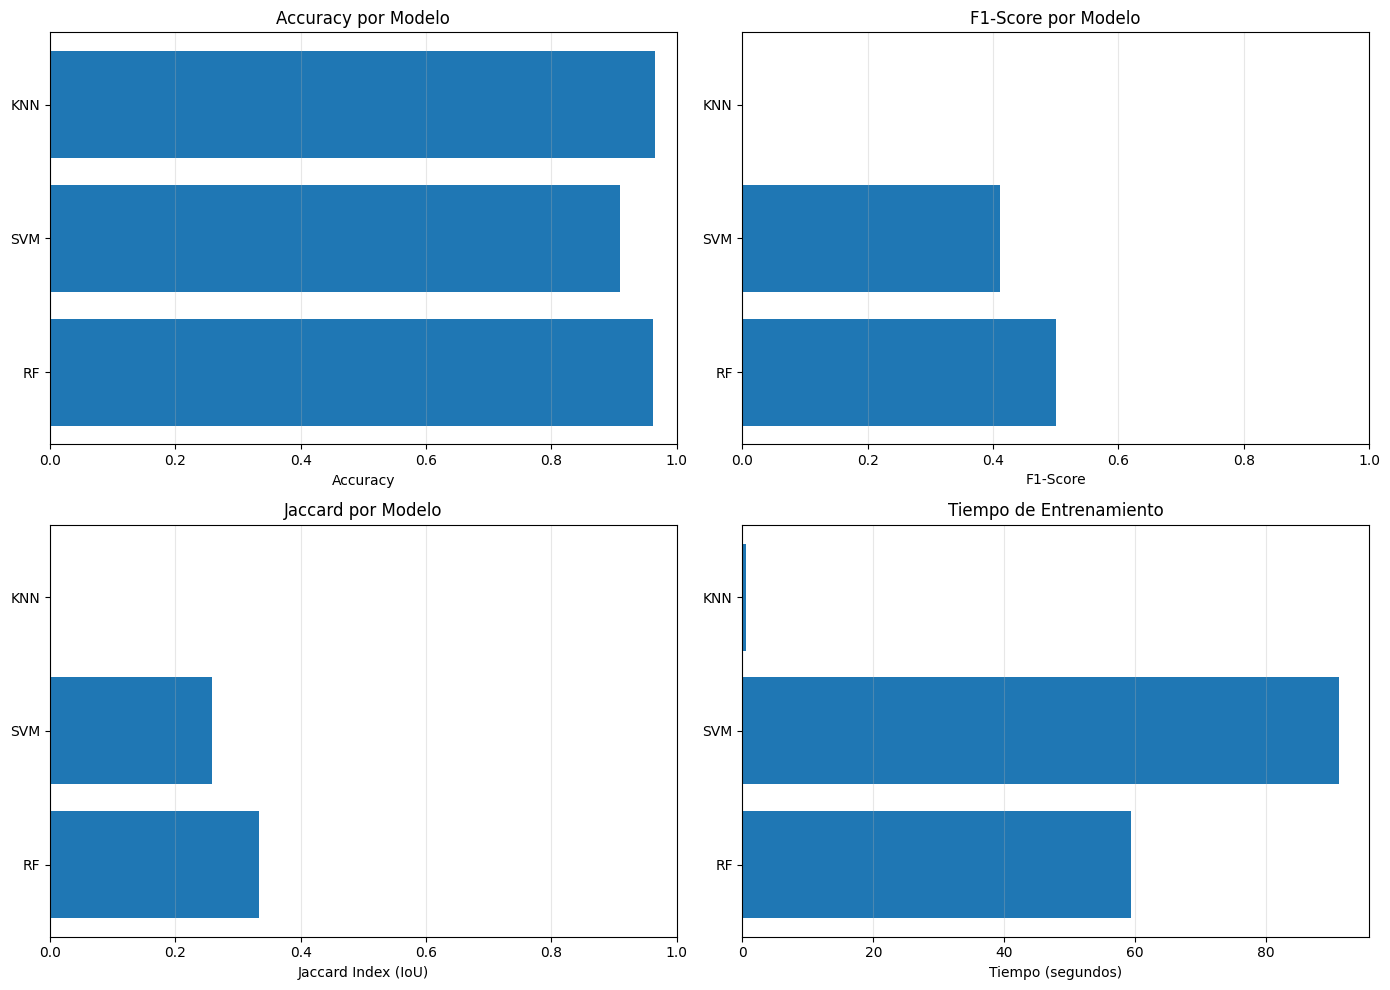

In [136]:
# Gráficos comparativos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Preparar datos para graficar
modelos = df_resultados['Modelo'].values
accuracy = df_resultados['Accuracy'].values
f1 = df_resultados['F1-Score'].values
jaccard = df_resultados['Jaccard (IoU)'].values
tiempo_train = df_resultados['Tiempo Train (s)'].values

# Accuracy
axes[0, 0].barh(modelos, accuracy)
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Accuracy por Modelo')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)

# F1-Score
axes[0, 1].barh(modelos, f1)
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('F1-Score por Modelo')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(axis='x', alpha=0.3)

# Jaccard (IoU)
axes[1, 0].barh(modelos, jaccard)
axes[1, 0].set_xlabel('Jaccard Index (IoU)')
axes[1, 0].set_title('Jaccard por Modelo')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(axis='x', alpha=0.3)

# Tiempo de entrenamiento
axes[1, 1].barh(modelos, tiempo_train)
axes[1, 1].set_xlabel('Tiempo (segundos)')
axes[1, 1].set_title('Tiempo de Entrenamiento')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Visualización de Predicciones

Comparamos visualmente las imágenes predichas con el ground truth

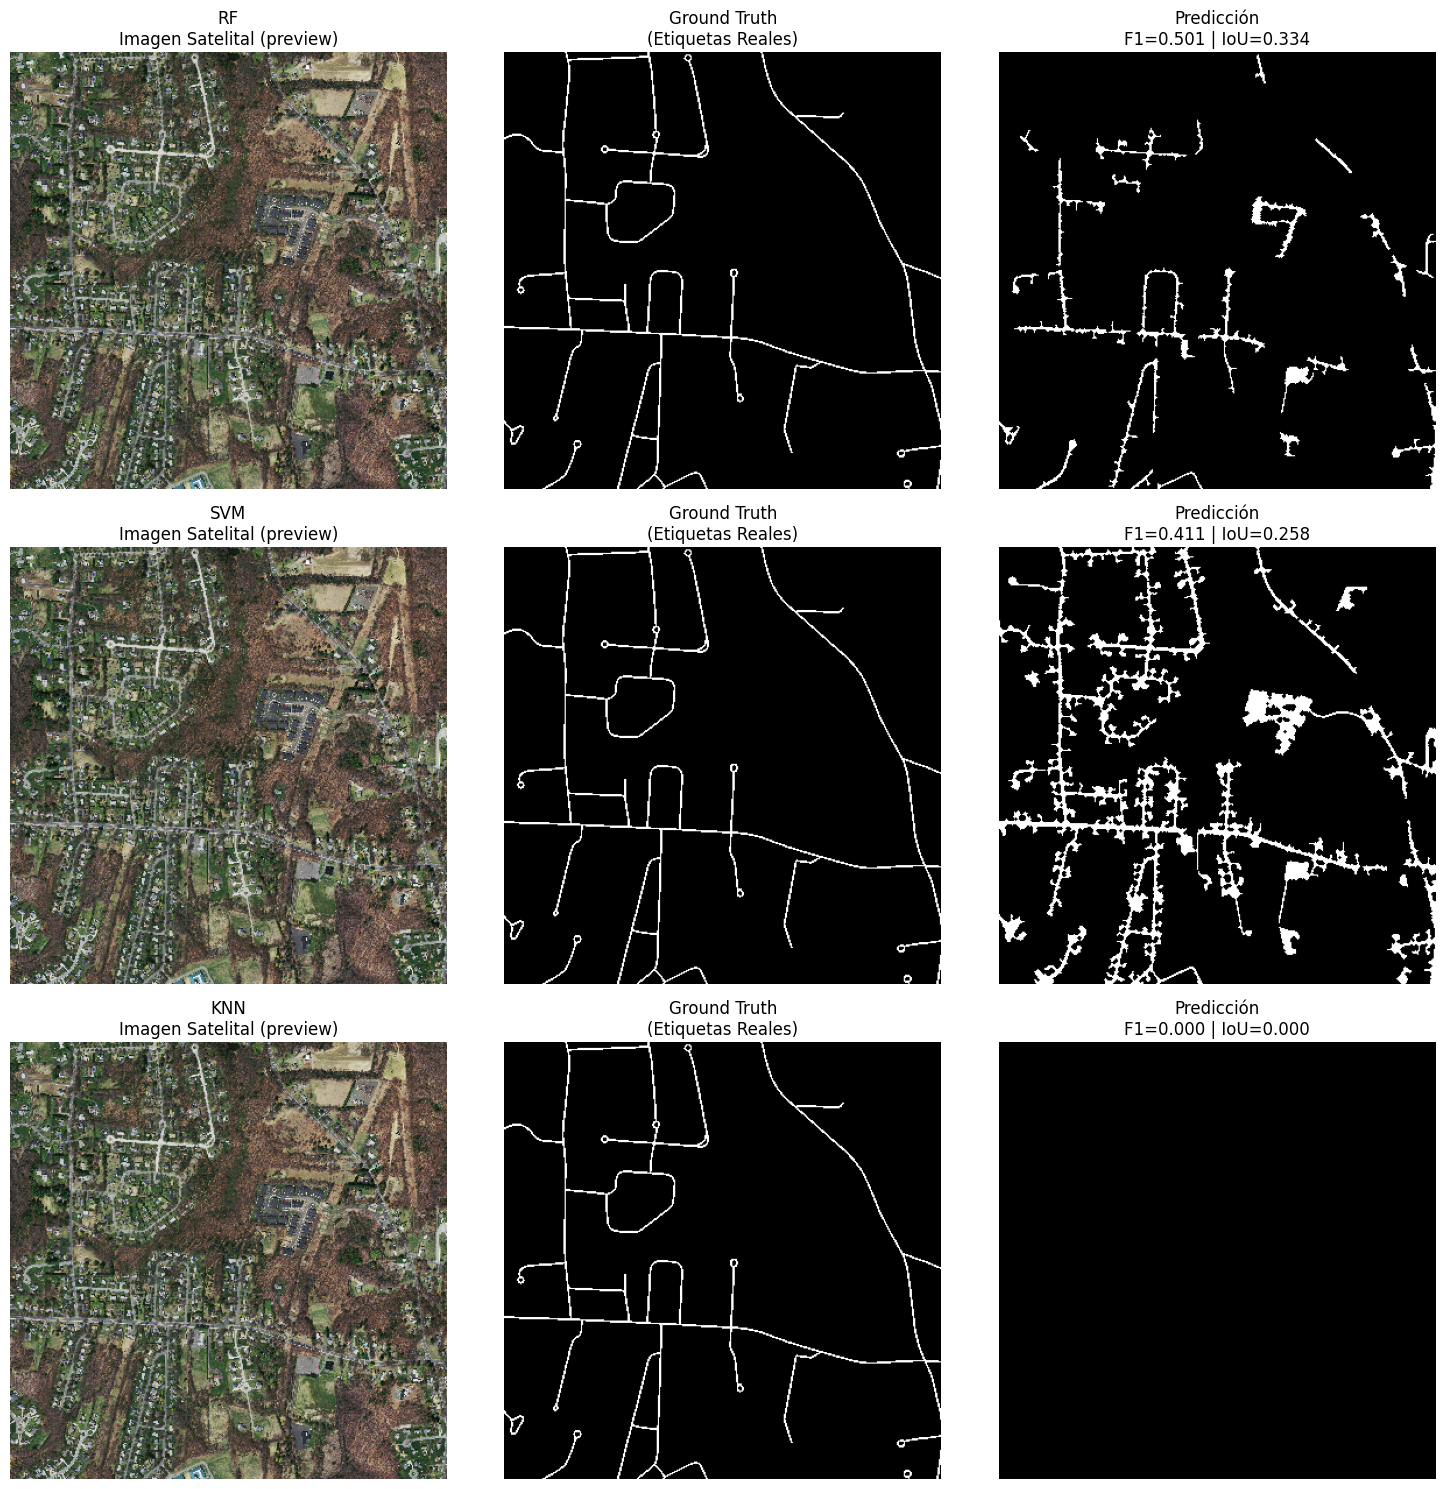

In [137]:
# Visualizar las 3 mejores predicciones
top3_modelos = df_resultados.head(3)['Modelo'].values

fig, axes = plt.subplots(len(top3_modelos), 3, figsize=(15, 5*len(top3_modelos)))

if len(top3_modelos) == 1:
    axes = axes.reshape(1, -1)

for i, modelo_nombre in enumerate(top3_modelos):
    pred_info = predicciones[modelo_nombre]
    # Reconstruir imagen predicha
    if 'pred_mask' in pred_info:
        img_pred = pred_info['pred_mask']
    else:
        img_pred = pred_info['y_pred'].reshape(H, W)
    
    # Métricas
    f1 = pred_info['f1_score']
    jaccard = pred_info['jaccard']
    
    # Imagen original (preview reducido)
    axes[i, 0].imshow(img_test_sat_small)
    axes[i, 0].set_title(f'{modelo_nombre}\nImagen Satelital (preview)')
    axes[i, 0].axis('off')
    
    # Ground truth (preview reducido)
    axes[i, 1].imshow(img_test_gt_small, cmap='gray')
    axes[i, 1].set_title('Ground Truth\n(Etiquetas Reales)')
    axes[i, 1].axis('off')
    
    # Predicción
    axes[i, 2].imshow(img_pred, cmap='gray')
    axes[i, 2].set_title(f'Predicción\nF1={f1:.3f} | IoU={jaccard:.3f}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## 9. Análisis de Resultados y Conclusiones

Interpreta los resultados obtenidos:

In [138]:
# Mejor modelo
mejor_modelo = df_resultados.iloc[0]
print(f"\n MEJOR MODELO: {mejor_modelo['Modelo']}")
print(f"   - Accuracy:  {mejor_modelo['Accuracy']:.4f}")
print(f"   - F1-Score:  {mejor_modelo['F1-Score']:.4f}")
print(f"   - Jaccard:   {mejor_modelo['Jaccard (IoU)']:.4f}")

# Velocidad
print("\n VELOCIDAD:")
mas_rapido = df_resultados.iloc[-1]
print(f"   Más rápido en train: {mas_rapido['Modelo']} ({mas_rapido['Tiempo Train (s)']:.2f}s)")



 MEJOR MODELO: RF
   - Accuracy:  0.9632
   - F1-Score:  0.5012
   - Jaccard:   0.3344

 VELOCIDAD:
   Más rápido en train: KNN (0.55s)
